In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/red-wine-quality-cortez-et-al-2009/winequality-red.csv


Dataset loaded successfully.
Shape: (1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4       

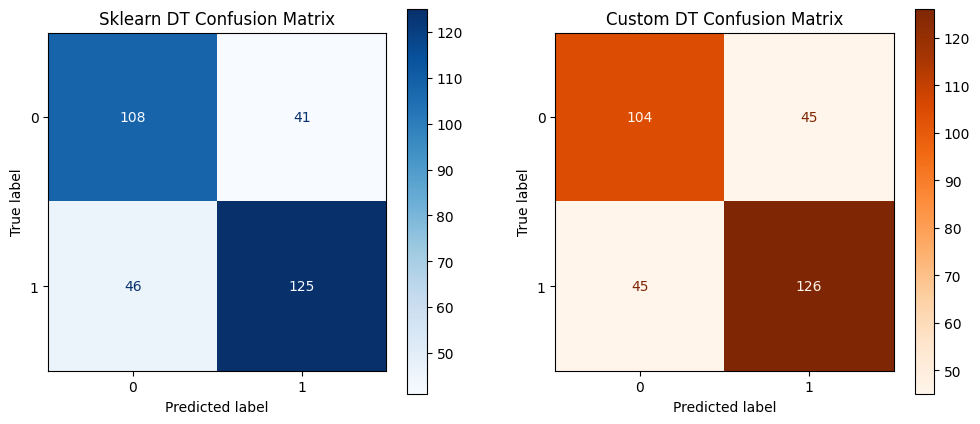

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv('/kaggle/input/red-wine-quality-cortez-et-al-2009/winequality-red.csv')
print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())
print(df.info())
print("Missing Values:\n", df.isnull().sum())

# Preprocess
df['quality'] = (df['quality'] >= 6).astype(int)
X = df.drop('quality', axis=1)
y = df['quality']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Features standardized.")

# Gini impurity
def gini_impurity(y):
    if len(y) == 0:
        return 0
    p = np.bincount(y) / len(y)
    return 1 - np.sum(p ** 2)

# Node class
class Node:
    def __init__(self, gini, samples, value, feature_index, threshold, left, right):
        self.gini = gini
        self.samples = samples
        self.value = value
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right

# Build custom tree
def build_tree(X, y, depth=0, max_depth=5):
    num_samples_per_class = [np.sum(y == c) for c in np.unique(y)]
    if len(np.unique(y)) == 1 or depth == max_depth:
        return Node(gini_impurity(y), len(y), np.argmax(num_samples_per_class), None, None, None, None)
    
    best_gini = float('inf')
    best_idx, best_thr = None, None
    
    for idx in range(X.shape[1]):
        thresholds = np.unique(X[:, idx])
        for thr in thresholds[:-1]:
            left_idx = X[:, idx] < thr
            right_idx = ~left_idx
            if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
                continue
            X_left, y_left = X[left_idx], y[left_idx]
            X_right, y_right = X[right_idx], y[right_idx]
            gini = (len(y_left) * gini_impurity(y_left) + len(y_right) * gini_impurity(y_right)) / len(y)
            if gini < best_gini:
                best_gini = gini
                best_idx = idx
                best_thr = thr
    
    if best_idx is None:
        return Node(gini_impurity(y), len(y), np.argmax(num_samples_per_class), None, None, None, None)
    
    left_idx = X[:, best_idx] < best_thr
    right_idx = ~left_idx
    X_left, y_left = X[left_idx], y[left_idx]
    X_right, y_right = X[right_idx], y[right_idx]
    node = Node(best_gini, len(y), None, best_idx, best_thr,
                build_tree(X_left, y_left, depth + 1, max_depth),
                build_tree(X_right, y_right, depth + 1, max_depth))
    return node

# Predict with custom tree
def predict_tree(node, X):
    if node.feature_index is None:
        return np.full(len(X), node.value)
    left_idx = X[:, node.feature_index] < node.threshold
    right_idx = ~left_idx
    y_pred = np.zeros(len(X))
    y_pred[left_idx] = predict_tree(node.left, X[left_idx])
    y_pred[right_idx] = predict_tree(node.right, X[right_idx])
    return y_pred

# Manual metrics
def calculate_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    acc = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    
    return acc, prec, rec, f1

# Train Sklearn DT
clf_sk = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_sk.fit(X_train, y_train)
y_pred_sk = clf_sk.predict(X_test)

# Train Custom DT
root = build_tree(X_train, y_train)
y_pred_custom = predict_tree(root, X_test)

# Metrics
print("Sklearn Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_sk))
print("Precision:", precision_score(y_test, y_pred_sk))
print("Recall:", recall_score(y_test, y_pred_sk))
print("F1-Score:", f1_score(y_test, y_pred_sk))

print("\nCustom Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1-Score:", f1_score(y_test, y_pred_custom))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sk, ax=axes[0], cmap='Blues')
axes[0].set_title('Sklearn DT Confusion Matrix')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, ax=axes[1], cmap='Oranges')
axes[1].set_title('Custom DT Confusion Matrix')
plt.show()